#### Cifar-10
---

In [1]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import platform


# OS에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')


# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

##### 라벨 보기
---

In [ ]:
import numpy as np
from tensorflow.keras.datasets import cifar10

# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. 클래스 이름 정의 (CIFAR-10 공식 순서)
classes = ['비행기', '자동차', '새', '고양이', '사슴', '개', '개구리', '말', '배', '트럭']

# 3. 데이터 차원 확인
print("==== 데이터 구조 확인 ====")
print(f"Train 이미지 차원: {x_train.shape}")  # (50000, 32, 32, 3) -> 5만장, 32x32 해상도, RGB 3채널
print(f"Train 라벨 차원: {y_train.shape}")    # (50000, 1)
print(f"Test 이미지 차원: {x_test.shape}")    # (10000, 32, 32, 3)
print(f"테스트 데이터 비율: {len(x_test) / (len(x_train) + len(x_test)) * 100:.1f}%")
print(f"픽셀 최솟값: {x_train.min()}, 최댓값: {x_train.max()}")

==== 데이터 구조 확인 ====
Train 이미지 차원: (50000, 32, 32, 3)
Train 라벨 차원: (50000, 1)
Test 이미지 차원: (10000, 32, 32, 3)
테스트 데이터 비율: 16.7%
픽셀 최솟값: 0, 최댓값: 255


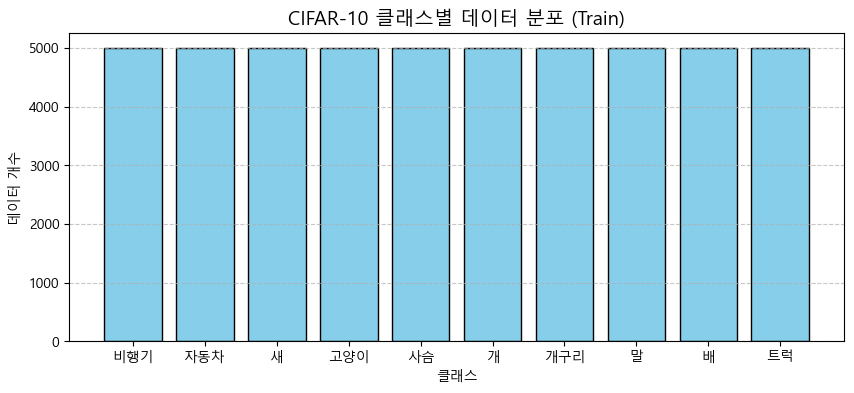

클래스별 개수: {'비행기': np.int64(5000), '자동차': np.int64(5000), '새': np.int64(5000), '고양이': np.int64(5000), '사슴': np.int64(5000), '개': np.int64(5000), '개구리': np.int64(5000), '말': np.int64(5000), '배': np.int64(5000), '트럭': np.int64(5000)}


In [8]:
# 클래스별 빈도수 계산
unique, counts = np.unique(y_train, return_counts=True)

# 시각화
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title('CIFAR-10 클래스별 데이터 분포 (Train)', fontsize=14)
plt.xlabel('클래스')
plt.ylabel('데이터 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("클래스별 개수:", dict(zip(classes, counts)))

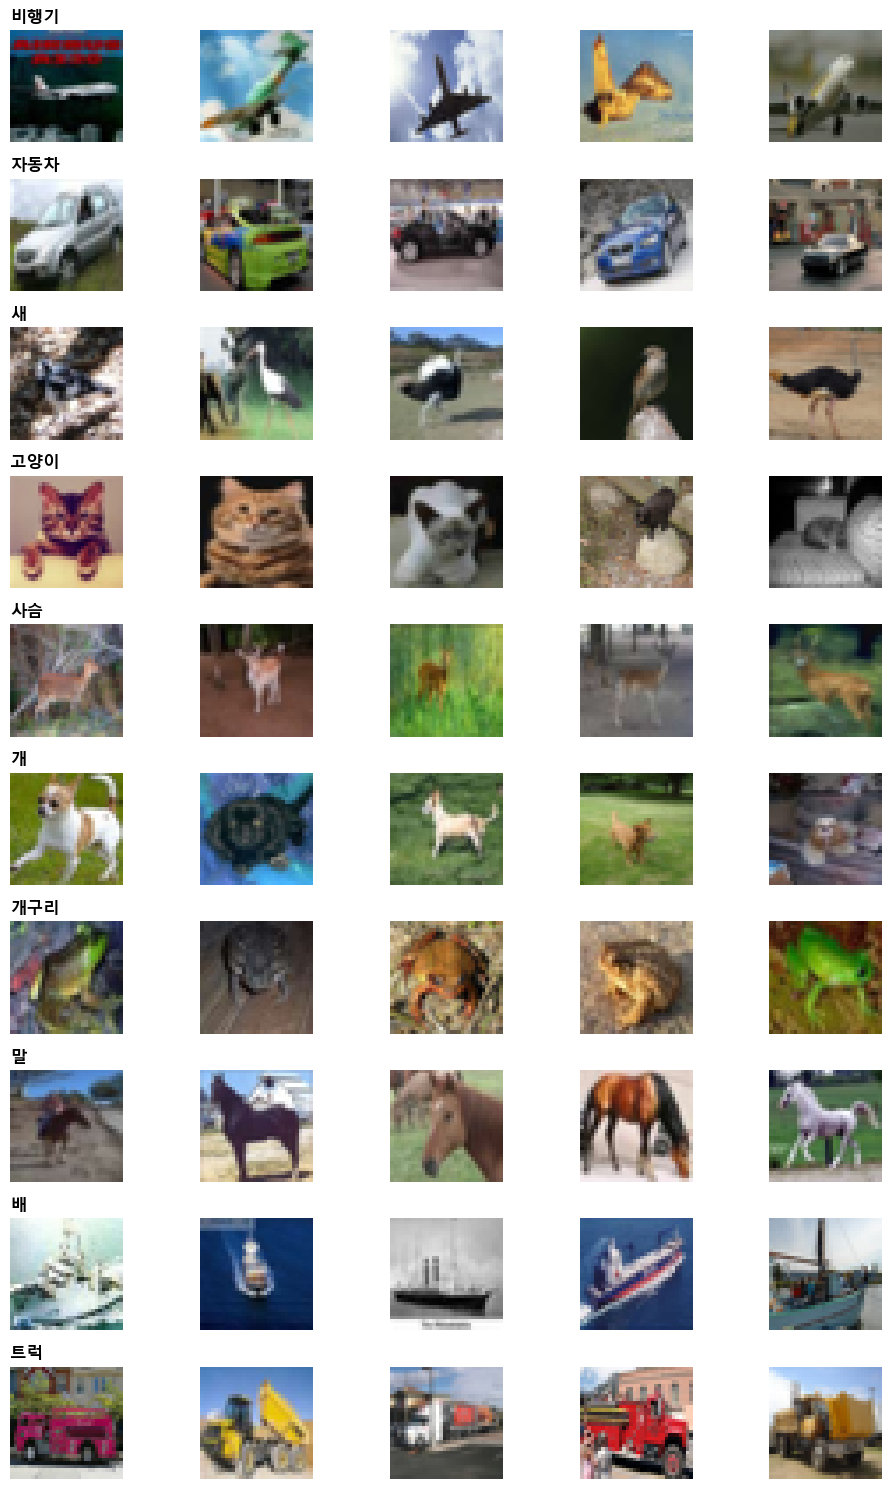

In [9]:
num_classes = 10
samples_per_class = 5

# 10행 5열의 서브플롯 생성
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 15))

for cluster_idx, class_name in enumerate(classes):
    # 해당 클래스의 인덱스만 추출
    idx = np.flatnonzero(y_train == cluster_idx)
    # 무작위로 5개 선택
    rand_idx = np.random.choice(idx, samples_per_class, replace=False)
    
    for i, img_idx in enumerate(rand_idx):
        ax = axes[cluster_idx, i]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        
        # 첫 번째 열에만 클래스 이름 표시
        if i == 0:
            ax.set_title(class_name, loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##### 데이터 불러오기

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

##### 학습, 검증 데이터 나누기

In [12]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    x_train, y_train, random_state=42, shuffle=True, stratify=y_train
)

In [13]:
print(train_input.shape, train_target.shape, val_input.shape, val_target.shape)

(37500, 32, 32, 3) (37500, 1) (12500, 32, 32, 3) (12500, 1)


##### 스케일링

In [32]:
# 이미 (37500, 32, 32, 3) 4차원 형태로 나뉘어져 있음. 스케일링만
train_scaled = train_input / 255.0
val_scaled = val_input / 255.0
test_scaled = x_test / 255.0

##### 모델 구성하기

In [33]:
cifar_model = keras.Sequential()

##### 입력층

In [34]:
cifar_model.add(keras.Input(shape=(32,32,3)))

##### Layer 1
---

In [35]:
cifar_model.add(
    keras.layers.Conv2D(64, 3, activation='relu', padding='same')
)
# (32, 32, 64), (3*3*3+1) * 64 = 1792

In [36]:
cifar_model.add(keras.layers.MaxPool2D(2))
# (16, 16, 64)

##### Layer 2
---

In [37]:
cifar_model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))
# (16, 16, 32), (3*3*64+1) * 32 = 18464

In [38]:
cifar_model.add(keras.layers.MaxPool2D(2))
# (8, 8, 32)

##### Full-Connected Layer
---

In [39]:
# 8 * 8 * 32 = 2048 (batch, 2048)
cifar_model.add(keras.layers.Flatten())
# 2048 * 128 + 128 = 262272
cifar_model.add(keras.layers.Dense(128, activation='relu'))
# 128 * 32 + 32 = 4128
cifar_model.add(keras.layers.Dense(32, activation='relu'))


##### 출력층

In [40]:
# 32 * 10 + 10 = 330
cifar_model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
# 드롭아웃
# cifar_model.add(keras.layers.Dropout(0.3))

In [41]:
cifar_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,986 (1.09 MB)

 Trainable params: 286,986 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

##### 모델 컴파일

In [42]:
cifar_model.compile(optimizer='adam',
                    loss=keras.losses.sparse_categorical_crossentropy,
                    metrics=['accuracy'], jit_compile=False)

##### 콜백 설정


In [ ]:
# checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
# early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [43]:
history = cifar_model.fit(train_scaled, train_target,
                          # callbacks=[checkpoint,early_stopping],
                          epochs=35,
                          validation_data=[val_scaled,val_target])

Epoch 1/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4510 - loss: 1.5074 - val_accuracy: 0.5614 - val_loss: 1.2336
Epoch 2/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5955 - loss: 1.1461 - val_accuracy: 0.5674 - val_loss: 1.2135
Epoch 3/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6515 - loss: 0.9869 - val_accuracy: 0.6513 - val_loss: 0.9949
Epoch 4/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6910 - loss: 0.8744 - val_accuracy: 0.6646 - val_loss: 0.9627
Epoch 5/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7220 - loss: 0.7906 - val_accuracy: 0.6706 - val_loss: 0.9762
Epoch 6/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7489 - loss: 0.7110 - val_accuracy: 0.6847 - val_loss: 0.9513
Epoch 7/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7746 - loss: 0.6398 - val_accuracy: 0.6807 - val_loss: 0.9650
Epoch 8/35
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7999 - lo

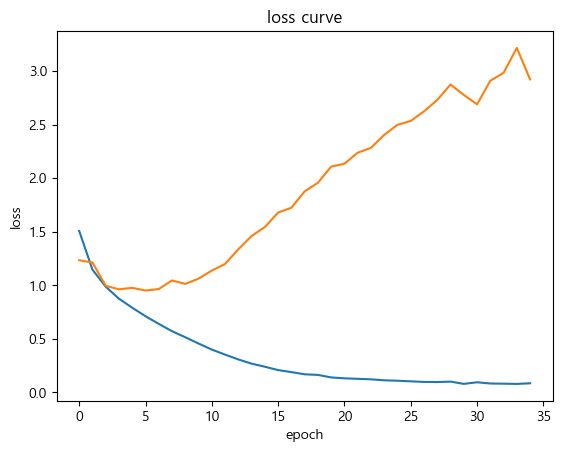

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve')
plt.show()

##### 1차 학습 결과
---

- 다중 분류인데 이진 분류의 탈을 쓴 손실 함수 : 손실 함수(Loss): loss='binary_crossentropy'
    - loss=keras.losses.sparse_categorical_crossentropy 로 했는데...?

- 정답 레이블(Target)의 데이터 형태 형태 불일치
    - ???

- 1차 학습 치고는 다소 거친 기본 학습률(Learning Rate)
    - CIFAR-10은 이미지 크기가 $32 \times 32$로 매우 작고 사물이 뭉개져 있어, MNIST 같은 숫자 데이터셋보다 패턴을 찾기가 훨씬 까다로움
    - Adam의 기본 학습률($0.001$)은 이 작고 복잡한 이미지 모델에게 첫 서치 단계치고는 보폭이 너무 넓은 편

- 모델의 표현력(Capacity)에 비해 너무 급격한 압축
    - 최종 Conv 레이어 직후: $8 \times 8 \times 32 = \mathbf{2,048}$ 차원
    - 첫 번째 Dense 레이어: Dense(128) ➡️ 128 차원으로 축소 (약 $1/16$ 압축)
    - 두 번째 Dense 레이어: Dense(32) ➡️ 32 차원으로 축소 (약 $1/4$ 압축)
    - 최종 출력 레이어: Dense(10)

    - 특징을 잘 뽑아 나가다가 Flatten 이후 첫 Dense 층에서 데이터를 2048개에서 128개로 너무 급격하게 깎아내 정보 유실 유력
---
구조 변경 : Conv, Dense 레이어 추가 - 완만한 차원축소 시도


##### 2차 학습
---

In [ ]:
cifar_model2 = keras.Sequential()

cifar_model2.add(keras.Input(shape=(32,32,3)))

cifar_model2.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same'))
cifar_model2.add(keras.layers.MaxPool2D(2))


cifar_model2.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))
cifar_model2.add(keras.layers.MaxPool2D(2))


# 추가
cifar_model2.add(keras.layers.Conv2D(16, 3, activation='relu', padding='same'))
cifar_model2.add(keras.layers.MaxPool2D(2))



cifar_model2.add(keras.layers.Flatten())

cifar_model2.add(keras.layers.Dense(128, activation='relu'))
cifar_model2.add(keras.layers.Dense(32, activation='relu'))

# 추가

cifar_model2.add(keras.layers.Dense(16, activation='relu'))

cifar_model2.add(keras.layers.Dense(10, activation='softmax'))

# 학습률(Learning Rate) 튜닝을 위해 객체로 지정하는 것을 추천!
optimizer_tuned = keras.optimizers.Adam(learning_rate=0.0003)
cifar_model2.compile(optimizer=optimizer_tuned,
                    loss=keras.losses.sparse_categorical_crossentropy,
                    metrics=['accuracy'], jit_compile=False)

cifar_model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,602 (244.54 KB)

 Trainable params: 62,602 (244.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3682 - loss: 1.7073 - val_accuracy: 0.4910 - val_loss: 1.4057
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5286 - loss: 1.3028 - val_accuracy: 0.5630 - val_loss: 1.2087
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5896 - loss: 1.1426 - val_accuracy: 0.6118 - val_loss: 1.0946
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6342 - loss: 1.0333 - val_accuracy: 0.6353 - val_loss: 1.0328
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6635 - loss: 0.9494 - val_accuracy: 0.6452 - val_loss: 1.0049
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6835 - loss: 0.8892 - val_accuracy: 0.6739 - val_loss: 0.9382
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7048 - loss: 0.8378 - val_accuracy: 0.6741 - val_loss: 0.9321
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7190 - loss: 0

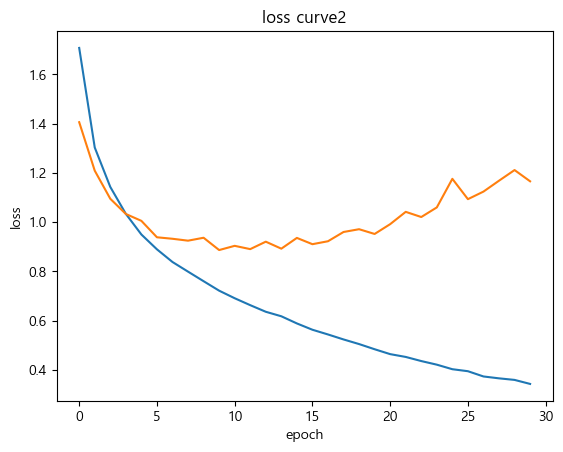

In [ ]:
history2 = cifar_model2.fit(train_scaled, train_target,
                          # callbacks=[checkpoint,early_stopping],
                          epochs=30,
                          validation_data=[val_scaled,val_target])

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve2')
plt.show()

##### 2차 학습 결과
---

- epoh 8 : accuracy 0.7190, loss 0.7986, val_accuracy 0.6789, val_loss 0.9244
- 이후 val_loss 가 널뛰기 시작하면서 과적합
    - 모델이 이미지의 일반적인 특징을 학습한 후 미세한 노이즈나 디테일을 외우기 시작(과적합)

    - 모델 표현력 과잉(파라미터수 과다 - Flatten 직후 Dense 층들의 원인일 확률 높음)
    - 브레이크(규제) 없음 - 드롭아웃 부재
    - 가파른 학습률 - 에포크 8까지 학습 후 보폭이 커져 튀는 현상

- 튜닝할 수 있는 부분
    - 모델 체급 줄이기(구조 튜닝)
        - Flatten 이후 Dense 층 노드 줄이기(128 -> 64, 32)
    - 드롭아웃 규제 추가
        - Dense층 사이 또는 Conv 층 다음에 추가해볼 것
    - 데이터 증강*
        - 증강 레이어를 추가해 모델을 헷갈리게 만들 것
    - 보폭 줄이기 & 조기 퇴근
        - learning_rate 줄이기
        - EarlyStopping 콜백 시도

---

- 드롭아웃 추가 후 3차 시도

##### 3차 학습
---


In [53]:
cifar_model3 = keras.Sequential()

cifar_model3.add(keras.Input(shape=(32,32,3)))

cifar_model3.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same'))
cifar_model3.add(keras.layers.MaxPool2D(2))


cifar_model3.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))
cifar_model3.add(keras.layers.MaxPool2D(2))


# 추가
cifar_model3.add(keras.layers.Conv2D(16, 3, activation='relu', padding='same'))
cifar_model3.add(keras.layers.MaxPool2D(2))



cifar_model3.add(keras.layers.Flatten())

cifar_model3.add(keras.layers.Dense(128, activation='relu'))
# 드롭아웃 추가
cifar_model3.add(keras.layers.Dropout(0.3))

cifar_model3.add(keras.layers.Dense(32, activation='relu'))
# 드롭아웃 추가
cifar_model3.add(keras.layers.Dropout(0.2))

cifar_model3.add(keras.layers.Dense(16, activation='relu'))

cifar_model3.add(keras.layers.Dense(10, activation='softmax'))

optimizer_tuned = keras.optimizers.Adam(learning_rate=0.0003)

cifar_model3.compile(optimizer=optimizer_tuned,
                    loss=keras.losses.sparse_categorical_crossentropy,
                    metrics=['accuracy'], jit_compile=False)

cifar_model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,602 (244.54 KB)

 Trainable params: 62,602 (244.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.2543 - loss: 1.9411 - val_accuracy: 0.3869 - val_loss: 1.6598
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3830 - loss: 1.6518 - val_accuracy: 0.4474 - val_loss: 1.5046
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4484 - loss: 1.5121 - val_accuracy: 0.5020 - val_loss: 1.3659
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4810 - loss: 1.4238 - val_accuracy: 0.5168 - val_loss: 1.3275
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5120 - loss: 1.3506 - val_accuracy: 0.5419 - val_loss: 1.2564
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5324 - loss: 1.2928 - val_accuracy: 0.5678 - val_loss: 1.2005
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5520 - loss: 1.2413 - val_accuracy: 0.5776 - val_loss: 1.1641
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5717 - loss: 1

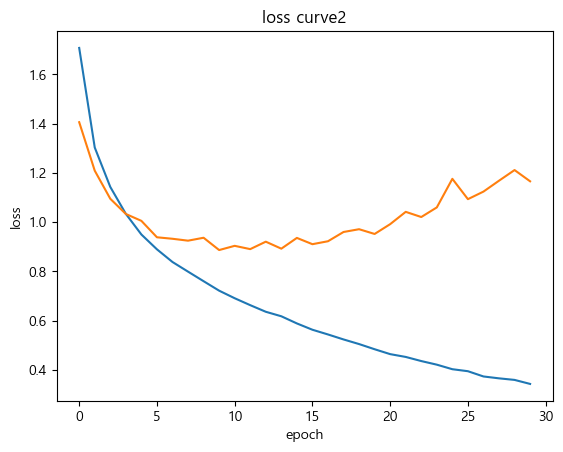

In [54]:
# 콜백 설정 추가
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history3 = cifar_model3.fit(train_scaled, train_target,
                          callbacks=[checkpoint,early_stopping],
                          epochs=30,
                          validation_data=[val_scaled,val_target])

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve2')
plt.show()

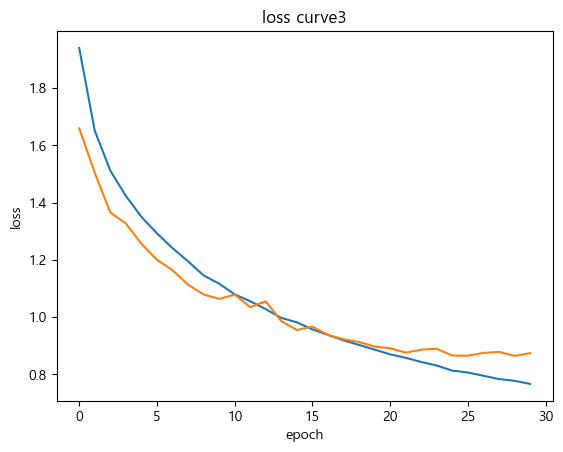

In [56]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve3')
plt.show()

##### 3차 학습 결과
---

- loss 그래프 안정
    - 9~10번 대에서 발생하던 격렬한 지그재그 현상 안정화
    - 드롭아웃 브레이크 덕분에 에포크 15~16번 근처까지 검증 데이터(val)와 훈련 데이터(train) loss가 비슷하게 내려감.
- 최종 accuracy 0.7347, val_accuracy 0.7010
    - 모델 지능을 올리기 위해 시도해볼 수 있는 것들
        - 필터 수 늘리기(CNN은 뒤로 갈수록 더 복잡하고 고차원적인 특징(사물의 형태, 바퀴, 눈코입 등)을 배워야 하므로 필터 수를 늘려주는 것이 정석)
            - Conv 필터 32 - 64 - 128 로 늘려보기
        - Conv 층 더 깊게 쌓기 (더 깊은 추론)
        - 배치 정규화(Batch Normalization) 시도 : 레이어를 거칠 때마다 데이터의 분포가 조금씩 틀어지는 현상(Internal Covariate Shift)을 막아줌
            : 학습 속도 증진, 자체적 규제 효과를 기대할 수 있음